In [22]:
!python --version
!pip install scipy==1.9.1
!pip install scikit-optimize

Python 3.8.10
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Naive Bayes


In [23]:
from sklearn.datasets import load_digits
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the data
X, y = load_digits(return_X_y=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the text data into a matrix of token counts
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Train a Naive Bayes classifier
clf = MultinomialNB()
clf.fit(X_train_counts, y_train)

# Evaluate the classifier on the testing set
y_pred = clf.predict(X_test_counts)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}".format(accuracy))


AttributeError: ignored

Gaussian NB

In [24]:
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the iris dataset
iris = load_iris()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

# Create a Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Fit the classifier to the training data
gnb.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = gnb.predict(X_test)

# Evaluate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.9777777777777777


Multinomial Naive Bayes

In [25]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB

# Load the iris dataset
iris = load_iris()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target,
                                                    test_size=0.2,
                                                    random_state=42)

# Create a Gaussian Naive Bayes classifier and fit it to the training data
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Evaluate the Gaussian Naive Bayes classifier on the test data
gnb_acc = gnb.score(X_test, y_test)
print(f"Gaussian Naive Bayes accuracy: {gnb_acc:.2f}")

# Create a Multinomial Naive Bayes classifier and fit it to the training data
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

# Evaluate the Multinomial Naive Bayes classifier on the test data
mnb_acc = mnb.score(X_test, y_test)
print(f"Multinomial Naive Bayes accuracy: {mnb_acc:.2f}")



Gaussian Naive Bayes accuracy: 1.00
Multinomial Naive Bayes accuracy: 0.90


In [26]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB

# Generate some classification data
X, y = [[[1, 2, 3, 4, 5], [1, 4, 105, 20, 4], [15, 2, 33, 4, 35], [1, 25, 12, 23, 41],
         [1, 23, 3, 4, 5], [1, 4, 10, 25, 4], [1, 2, 35, 3, 5], [1, 2, 12, 23, 4]], [1, 2, 4, 2, 3, 1, 2, 1]]

print(X)
print(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)



# Create a Gaussian Naive Bayes classifier and fit it to the training data
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Evaluate the accuracy of the Gaussian Naive Bayes classifier on the test data
gnb_score = gnb.score(X_test, y_test)
print(f"Gaussian Naive Bayes accuracy: {gnb_score:.3f}")

# Create a Multinomial Naive Bayes classifier and fit it to the training data
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

# Evaluate the accuracy of the Multinomial Naive Bayes classifier on the test data
mnb_score = mnb.score(X_test, y_test)
print(f"Multinomial Naive Bayes accuracy: {mnb_score:.3f}")


[[1, 2, 3, 4, 5], [1, 4, 105, 20, 4], [15, 2, 33, 4, 35], [1, 25, 12, 23, 41], [1, 23, 3, 4, 5], [1, 4, 10, 25, 4], [1, 2, 35, 3, 5], [1, 2, 12, 23, 4]]
[1, 2, 4, 2, 3, 1, 2, 1]
Gaussian Naive Bayes accuracy: 0.500
Multinomial Naive Bayes accuracy: 1.000


Kernel Gaus

In [27]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import numpy as np
import matplotlib.pyplot as plt
# create some sample data
X = np.array([[-1, 1], [0, 2], [1, 3], [2, 4], [3, 5], [4, 6]])
y = np.array([0, 1, 2, 3, 4, 5])

# define the kernel
kernel = RBF(length_scale=1.0)

# create the Gaussian Process Regressor
gp = GaussianProcessRegressor(kernel=kernel)

# fit the data to the Gaussian Process Regressor
gp.fit(X, y)

# predict on new data
X_new = np.array([[5, 7], [6, 8], [7, 9]])
y_pred = gp.predict(X_new)

# print the predicted values
print(y_pred)








[5.26423581 4.09910491 2.23275975]


Gaussian Process

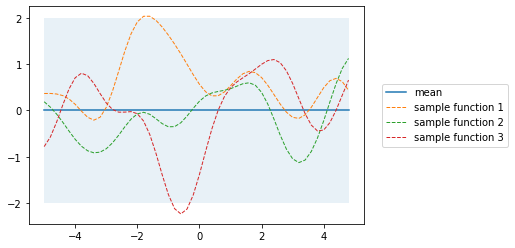

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

# cov
def kernel(X1, X2, l=1.0, sigma_f=1.0):
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return sigma_f**2 * np.exp(-0.5 / l**2 * sqdist)


# Plot functions
def plot_gp(mu, cov, X, X_train=None, Y_train=None, samples=[]):
    X = X.ravel()
    mu = mu.ravel()
    # 2 sigma
    uncertainty = 2 * np.sqrt(np.diag(cov))
    
    plt.fill_between(X, mu + uncertainty, mu - uncertainty, alpha=0.1)
    
    plt.plot(X, mu, label='mean')
    for i, sample in enumerate(samples):
        plt.plot(X, sample, lw=1, ls='--', label=f'sample function {i+1}')
    if X_train is not None:
        plt.plot(X_train, Y_train, 'rx')
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left")

def plot_gp_2D(gx, gy, mu, X_train, Y_train, title, i):
    ax = plt.gcf().add_subplot(1, 2, i, projection='3d')
    ax.plot_surface(gx, gy, mu.reshape(gx.shape), cmap=cm.coolwarm, linewidth=0, alpha=0.2, antialiased=False)
    ax.scatter(X_train[:,0], X_train[:,1], Y_train, c=Y_train, cmap=cm.coolwarm)
    ax.set_title(title)



# limit input data, 50 points
X = np.arange(-5, 5, 0.2).reshape(-1, 1)

# prior mean and cov
mu = np.zeros(X.shape)
cov = kernel(X, X)

# draw samples from prior multivarate Gaussian
samples = np.random.multivariate_normal(mu.ravel(), cov, 3)

# plot mean and confidence (2 sigma)
plot_gp(mu, cov, X, samples=samples)

Gaussian Process for Regression

In [ ]:
from numpy.linalg import inv

def posterior_predictive(X_s, X_train, Y_train, l=1.0, sigma_f=1.0, sigma_y=1e-8):

    K = kernel(X_train, X_train, l, sigma_f) + sigma_y**2 * np.eye(len(X_train))
    K_s = kernel(X_train, X_s, l, sigma_f)
    K_ss = kernel(X_s, X_s, l, sigma_f) + 1e-8 * np.eye(len(X_s))
    K_inv = inv(K)
    
    # Eq (4)
    mu_s = K_s.T.dot(K_inv).dot(Y_train)

    # Eq (5)
    cov_s = K_ss - K_s.T.dot(K_inv).dot(K_s)
    
    return mu_s, cov_s


# Only 5 inputs w/o noise
X_train = np.array([-4, -3, -2, -1, 1, 2, 3, 4]).reshape(-1, 1)

## the function is y =sin(x)
Y_train = np.sin(X_train)

# calculate posterior mean and cov 
mu_s, cov_s = posterior_predictive(X, X_train, Y_train)

# draw 3 samples from posterior 
samples = np.random.multivariate_normal(mu_s.ravel(), cov_s, 3)
plot_gp(mu_s, cov_s, X, X_train=X_train, Y_train=Y_train, samples=samples)






In [ ]:
# inputs w/ noise

noise = 0.4

# train data w/ noise
X_train = np.arange(-3, 4, 1).reshape(-1, 1)
Y_train = np.sin(X_train) + noise * np.random.randn(*X_train.shape)

In [ ]:
# calcuate posterior mean and cov
mu_s, cov_s = posterior_predictive(X, X_train, Y_train, sigma_y=noise)

# draw 3 samples from posterior 
samples = np.random.multivariate_normal(mu_s.ravel(), cov_s, 3)
plot_gp(mu_s, cov_s, X, X_train=X_train, Y_train=Y_train, samples=samples)


In [ ]:
# Tune parameters of Gaussian Kernel

params = [
    (0.3, 1.0, 0.2),
    (3.0, 1.0, 0.2),
    (1.0, 0.3, 0.2),
    (1.0, 3.0, 0.2),
    (1.0, 1.0, 0.05),
    (1.0, 1.0, 1.5),
]

plt.figure(figsize=(12, 5))

# Given the same training data, 7 points only
for i, (l, sigma_f, sigma_y) in enumerate(params):
    mu_s, cov_s = posterior_predictive(X, X_train, Y_train, l=l, 
                                       sigma_f=sigma_f, 
                                       sigma_y=sigma_y)
    plt.subplot(3, 2, i + 1)
    plt.subplots_adjust(top=2)
    plt.title(f'l = {l}, sigma_f = {sigma_f}, sigma_y = {sigma_y}')
    plot_gp(mu_s, cov_s, X, X_train=X_train, Y_train=Y_train)

In [ ]:
from numpy.linalg import cholesky, det, lstsq
from scipy.optimize import minimize

def nll_fn(X_train, Y_train, noise, naive=True):
    
    def nll_naive(theta):

        K = kernel(X_train, X_train, l=theta[0], sigma_f=theta[1]) + \
            noise**2 * np.eye(len(X_train))
        return 0.5 * np.log(det(K)) + \
               0.5 * Y_train.T.dot(inv(K).dot(Y_train)) + \
               0.5 * len(X_train) * np.log(2*np.pi)

    def nll_stable(theta):

        K = kernel(X_train, X_train, l=theta[0], sigma_f=theta[1]) + \
            noise**2 * np.eye(len(X_train))
        L = cholesky(K)
        return np.sum(np.log(np.diagonal(L))) + \
               0.5 * Y_train.T.dot(lstsq(L.T, lstsq(L, Y_train)[0])[0]) + \
               0.5 * len(X_train) * np.log(2*np.pi)
    
    if naive:
        return nll_naive
    else:
        return nll_stable


res = minimize(nll_fn(X_train, Y_train, noise), [1, 1], 
               bounds=((1e-5, None), (1e-5, None)),
               method='L-BFGS-B')

l_opt, sigma_f_opt = res.x

mu_s, cov_s = posterior_predictive(X, X_train, Y_train, l=l_opt, sigma_f=sigma_f_opt, sigma_y=noise)
plot_gp(mu_s, cov_s, X, X_train=X_train, Y_train=Y_train)

acquisition

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from skopt import gp_minimize

# Define the search space
bounds = [(-5.0, 5.0), (-5.0, 5.0)]

# Define the kernel for the Gaussian Process
kernel = Matern(length_scale=1.0, nu=2.5)

# Initialize the Gaussian Process
gp = GaussianProcessRegressor(kernel=kernel)



# Define a function to optimize (in this case, the Rosenbrock function)
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# Perform Bayesian optimization


res = gp_minimize(rosenbrock, bounds, n_calls=20, random_state=0, acq_func="EI")

# Print the optimized result
print("Optimized result: {}".format(res.x))


cov matrix

In [ ]:
import numpy as np

# Define the input data
X = np.array([[0, 1], [2, 3], [4, 5]])

# Define the length scale parameter
length_scale = 1.0

# Compute the pairwise Euclidean distances between the input data points
distances = np.sqrt(((X[:, np.newaxis, :] - X) ** 2).sum(axis=2))

# Compute the Gaussian covariance matrix
covariance_matrix = np.exp(-0.5 * (distances / length_scale) ** 2)

print(covariance_matrix)


Conditional Gaussian distribution 

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

# Define the mean and covariance matrices
mu_x = np.array([0.0, 0.0])
cov_x = np.array([[1.0, 0.5], [0.5, 1.0]])

mu_y_given_x = lambda x: np.array([x[0], x[1]**2])
cov_y_given_x = np.array([[0.1, 0.0], [0.0, 0.1]])

# Define the input value of x
x = np.array([1.0, 2.0])

# Compute the conditional mean and covariance matrices
mu_y = mu_y_given_x(x)
cov_y = cov_y_given_x

# Define the conditional Gaussian distribution
conditional_dist = multivariate_normal(mean=mu_y, cov=cov_y)

# Sample from the conditional distribution
samples = conditional_dist.rvs(size=10)

print(samples)


bayesian linear regression

In [ ]:
from sklearn.linear_model import BayesianRidge
from sklearn.datasets import make_regression

# Generate a random regression dataset
X, y = make_regression(n_samples=100, n_features=10, n_informative=5, noise=0.5)

# Fit the Bayesian Ridge model to the data
model = BayesianRidge()
model.fit(X, y)

# Print the posterior mean and standard deviation for the coefficients
for i in range(X.shape[1]):
    print(f"Coefficient {i}: {model.coef_[i]:.2f} +/- {np.sqrt(model.alpha_) * model.sigma_:.2f}")
print(f"Intercept: {model.intercept_:.2f} +/- {np.sqrt(model.lambda_) * model.sigma_:.2f}")



In [ ]:
from sklearn.linear_model import BayesianRidge
import numpy as np
 
# Generate some sample data
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2*X[:, 0] + 1 + np.random.normal(0, 1, 100)

# Fit the Bayesian Ridge model to the data
model = BayesianRidge()
model.fit(X, y)

# Print the posterior mean and standard deviation for the coefficients
print(model.intercept_:.2f,  np.sqrt(model.lambda_) * model.sigma_:.2f)
print(f"Slope: {model.coef_[0]:.2f} +/- {np.sqrt(model.alpha_) * model.sigma_:.2f}")
